In [13]:
from skimage.io import imread
import numpy as np
from scipy.fft import dct, idct
from scipy.signal import convolve2d
from matplotlib import pyplot as plt
import time

In [14]:
rootfolder = "../"

# Denoising

The goal of this section is to implement a simple denoising algorithm based on the 2D DCT. Given a noise free image $Y$, we observe a noisy version $S$:
$$
S = Y + \eta
$$
where $\eta\sim N(0, \sigma^2)$ denotes white Gaussian noise.

Our goal is to compute an estimate $\widehat Y$ of the original image $Y$. To evaluate the performance of the denoising algorithm we use again the PSNR:
$$
\text{PSNR} = 10\log_{10}\frac{1}{\text{MSE}(Y, \widehat Y)}
$$

## Synthetically corrupt an noisy image

Load the image and rescale it in $[0,1]$

In [15]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255  #/data/checkerboard.png
imsz = img.shape

Corrupt the image with white gaussian noise

In [16]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the psnr of the noisy input

In [17]:
### VER 1 ###
# err_sum = 0
# for i in range(imsz[0]):
#     for j in range(imsz[1]):
#         err_sum += (img[i, j] - noisy_img[i, j])**2
# mse = err_sum / (imsz[0] * imsz[1])

### VER 2 ###
mse = np.mean((img - noisy_img)**2)

psnr_noisy = 10 * np.log10(1 / mse)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

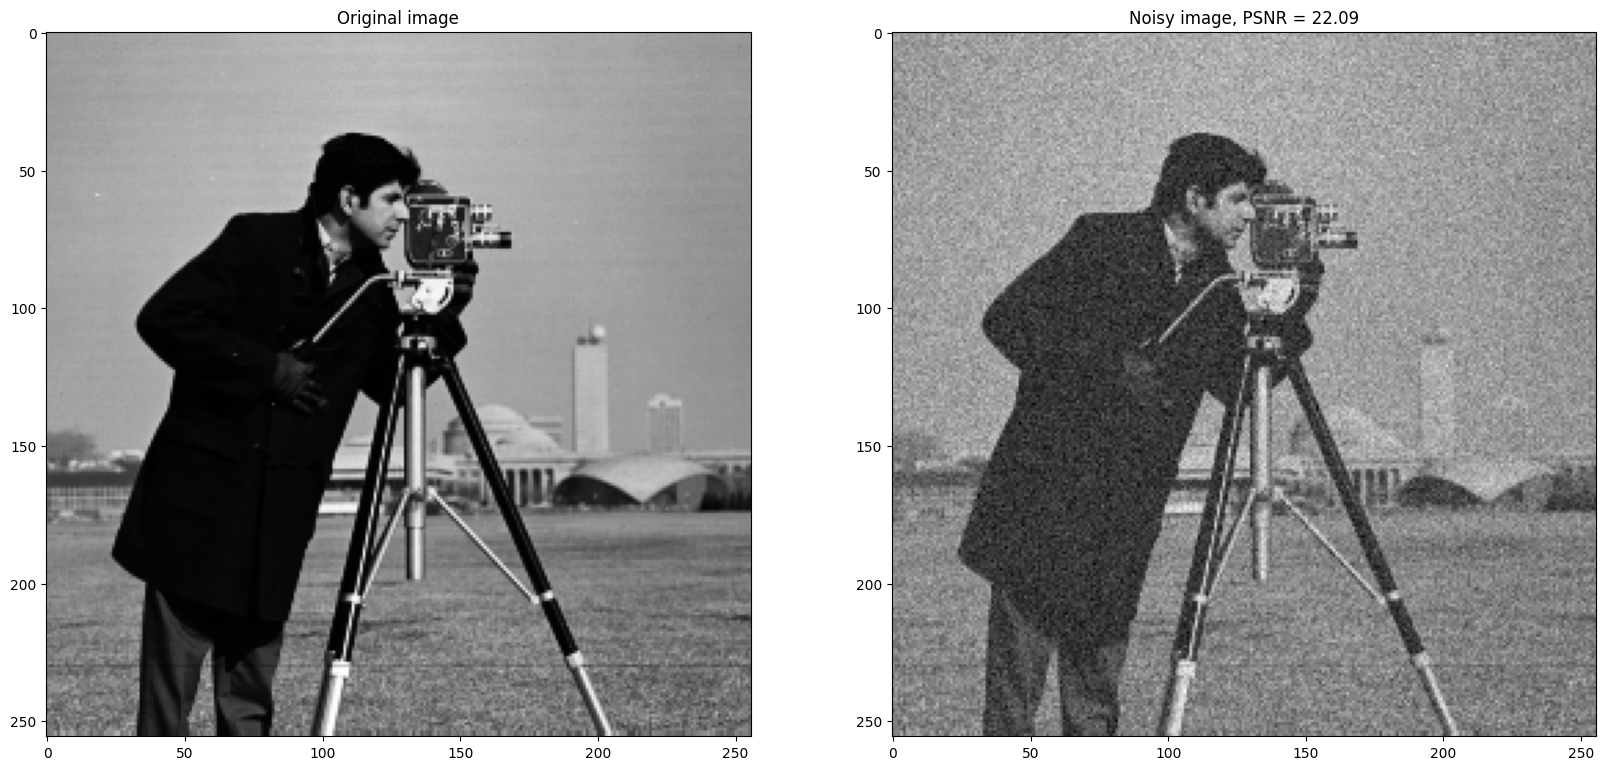

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Noise estimation
----------------
Compute the horizontal derivative of the image

In [19]:
# I used the convolution operation to compute differences where the kernel is [1, -1] (I could also have used kernel [-1, 1])
differences = convolve2d(img, np.array([[1, -1]]), mode='same')

Compute sigma as the empirical std

In [20]:
sigma_hat_emp = np.sqrt(np.var(differences) / 2)

Use MAD to estimate the noise level sigma

In [21]:
mad = lambda x: np.median(np.abs(x - np.median(x)))
sigma_hat = mad(convolve2d(noisy_img, np.array([[-1, 1]]), mode='same')) / (np.sqrt(2) * 0.6745)

In [22]:
print(f'sigma: {sigma_noise:.3f}, sigma_hat (empirical std): {sigma_hat_emp:.3f}, sigma_hat (MAD): {sigma_hat:.3f}')

sigma: 0.078, sigma_hat (empirical std): 0.068, sigma_hat (MAD): 0.087


## Denoising by Smoothing
Implement Denoising by Smoothing using convolution against a uniform filter of different size.

Let $k$ be the size of the filter.  
The filter $h$ is a $k \times k$ matrix defined as: $h(i,j) = \frac{1}{k^2} \qquad \text{for every } i,j$

In [23]:
filter_size = 3

filter = np.ones([filter_size, filter_size]) / filter_size**2

# compute the convolution with convolve2d()
img_hat_conv = convolve2d(noisy_img, filter, mode='same', boundary='symm')

In [24]:
psnr_conv = 10 * np.log10(1 / np.mean((img - img_hat_conv)**2))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

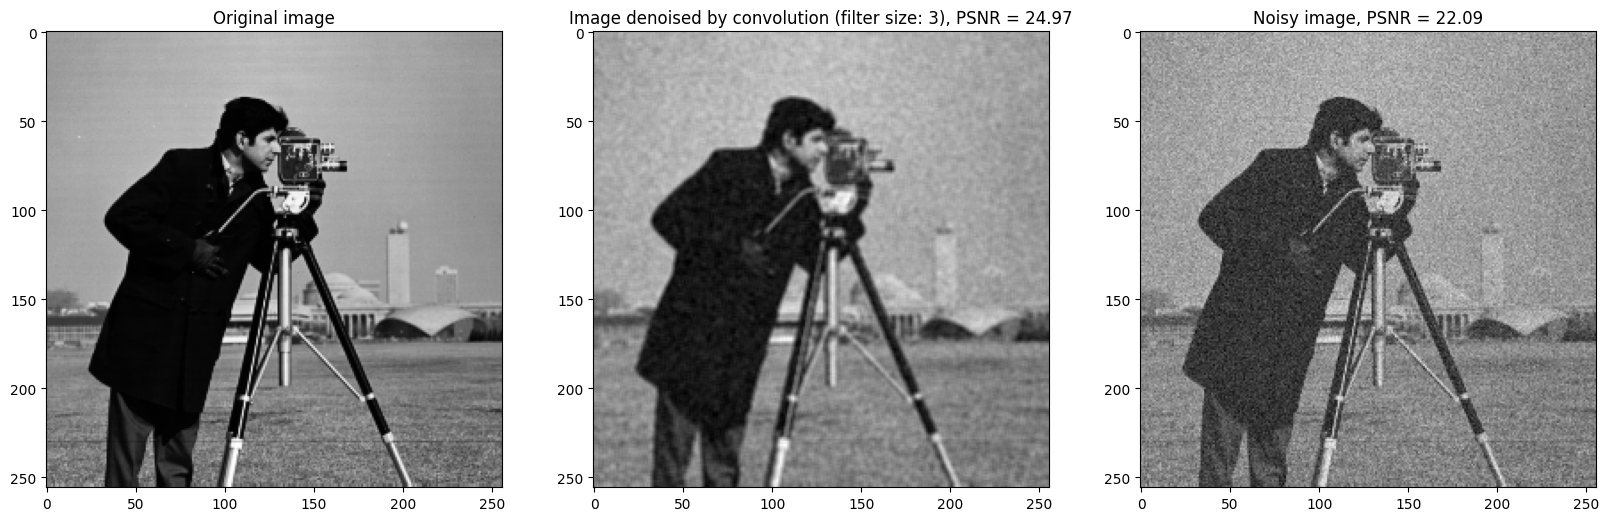

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(img_hat_conv, cmap='gray')
ax[1].set_title(f'Image denoised by convolution (filter size: {filter_size}), PSNR = {psnr_conv:.2f}')

ax[2].imshow(noisy_img, cmap='gray')
ax[2].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

## Denoising by Leveraging Sparsity in the DCT Domain

Definition of dct2 and idct2 (they are not builtin functions)

In [26]:
def dct2(s):
    return dct(dct(s.T, norm='ortho').T, norm='ortho')

def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

In [27]:
# patch size
p = 8

# number of elements in the patch
M = p ** 2

Useful function for plot the 2D DCT dictionary

In [28]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Sliding DCT denoising
-------------
Generate the DCT basis

In [29]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        a = np.zeros((p, p))
        a[i, j] = 1  
        D[:, cnt] = idct2(a).flatten()
        cnt += 1 

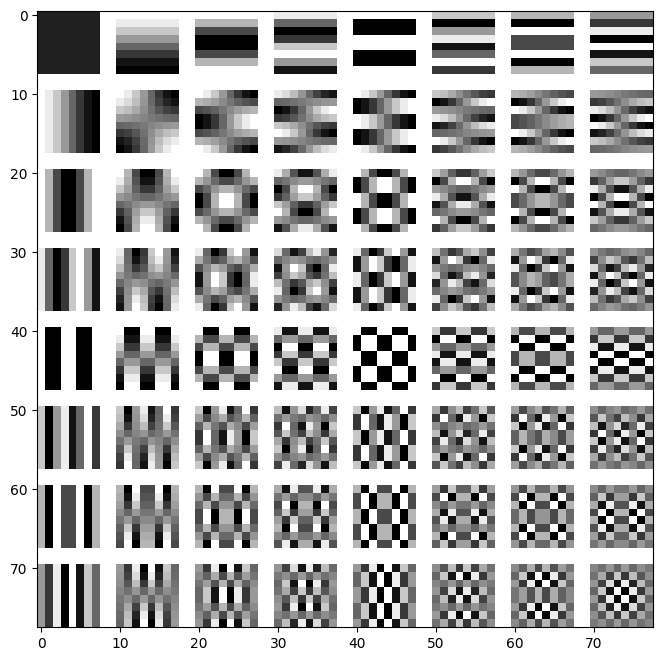

In [30]:
D_img = get_dictionary_img(D)
plt.figure(figsize=(8, 8))
plt.imshow(D_img, cmap='gray')

Denoising: set parameters and initialize the variables

In [31]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

# set the threshold for the Hard Thresholding
tau = 3 * sigma_noise # Donoho says: sigma * sqrt(2*log(p^2))

# define the step
STEP = 1

Perform the denoising patchwise

In [32]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i : i+p, j : j+p]
        
        # compute the representation w.r.t. the 2D DCT dictionary
        x = D.T @ s.reshape(-1)

        # perform the hard thresholding (do not perform HT on the DC!)
        x_HT = x.copy()
        x_HT[1:] = np.where(np.abs(x[1:]) <= tau, 0, x[1:])
        
        # perform the reconstruction
        s_hat = (D @ x_HT).reshape(p, p)

        # compute the weights to be used for aggregating the reconstructed patch
        # w = 1 # uniform weights
        w = 1 / np.count_nonzero(x_HT) # sparsity-aware weights

        # accumulate by summation the denoised patch into the denoised image using the computed weight
        # update img_hat
        img_hat[i : i+p, j : j+p] += w * s_hat

        # accumulate by summation the weights of the current patch in the weight matrix
        # update weights
        weights[i : i+p, j : j+p] += w

Normalize the estimated image with the computed weights, i.e. compute averages

In [33]:
img_hat = img_hat / weights

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image (step: 1), PSNR = 29.20')

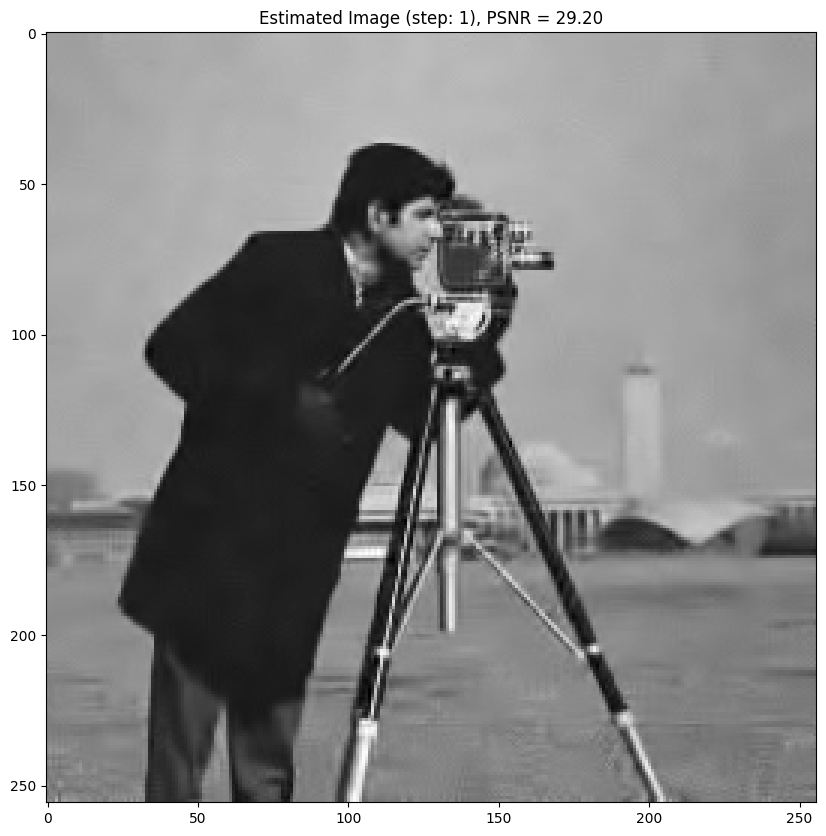

In [34]:
psnr_hat = 10 * np.log10(1 / np.mean((img - img_hat)**2))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image (step: {STEP}), PSNR = {psnr_hat:.2f}')

Wiener Filtering
----------------
Initialize the estimated image via Wiener Filtering

In [35]:
img_hat_wiener = np.zeros_like(img)
weights = np.zeros_like(img)

Perform the denoising patchwise

In [36]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch from the noisy image with the top left corner at pixel (ii, jj)
        s = noisy_img[i : i+p, j : j+p]

        # compute the representation w.r.t. the 2D DCT dictionary
        x = D.T @ s.reshape(-1)

        # extrach the patch from the image estimated by HT with the top left corner at pixel (ii, jj)
        x_HT = x.copy()
        x_HT[1:] = np.where(np.abs(x[1:]) <= tau, 0, x[1:])
        s_hat_HT = (D @ x_HT).reshape(p, p)

        # perform the Wiener filtering (do not filter the DC!)
        v_HT = D.T @ s_hat_HT.reshape(-1)
        x_wie = v_HT**2 / (v_HT**2 + sigma_noise**2) * x
        x_wie[0] = x[0]
        
        # perform the reconstruction
        s_hat_wie = (D @ x_wie).reshape(p, p)

        # use uniform weights to aggregate the multiple estimates
        w = 1

        # put the denoised patch into the denoised image using the computed weight
        # update img_hat_wiener
        img_hat_wiener[i : i+p, j : j+p] += w * s_hat_wie

        # store the weight of the current patch in the weight matrix
        # update weights
        weights[i : i+p, j : j+p] += w

# Normalize the estimated image with the computed weights
img_hat_wiener = img_hat_wiener / weights

Compute the PSNR of the two estimates

Text(0.5, 1.0, 'Wiener Estimate, PSNR = 29.07')

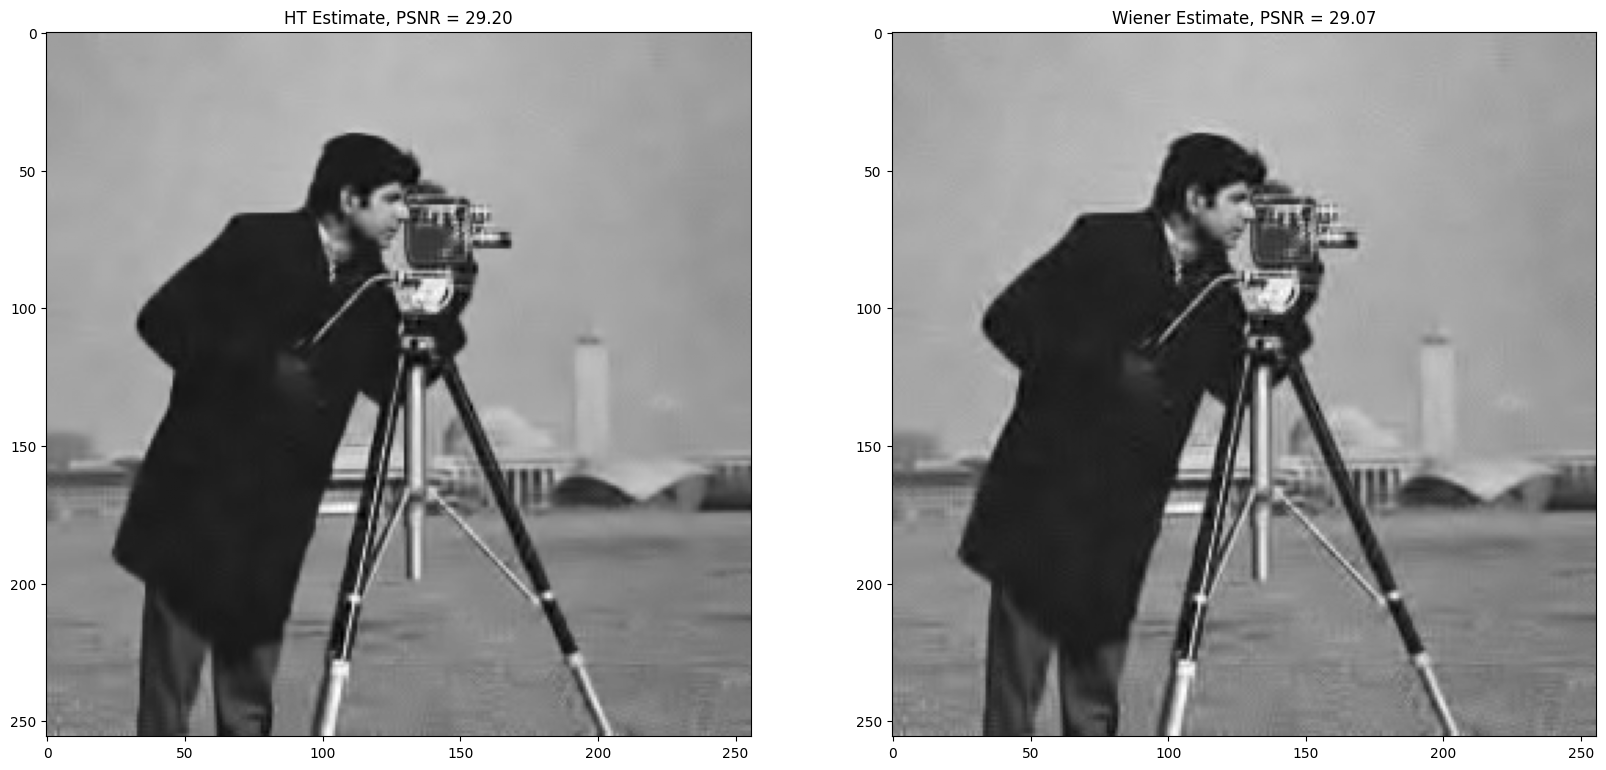

In [37]:
psnr_wiener = 10 * np.log10(1 / np.mean((img - img_hat_wiener)**2))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'HT Estimate, PSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_wiener, cmap='gray')
ax[1].set_title(f'Wiener Estimate, PSNR = {psnr_wiener:.2f}')